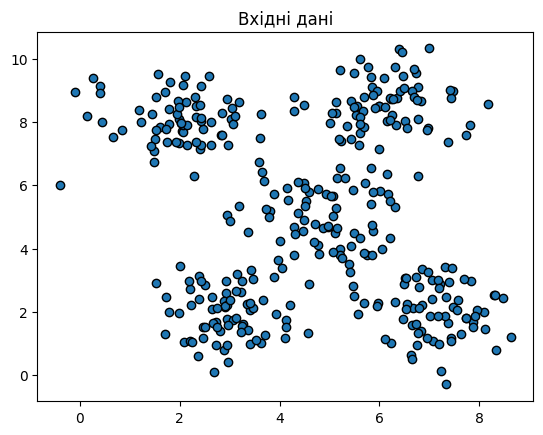

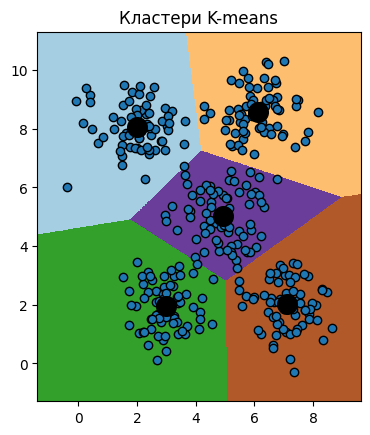

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Завантаження даних
X = np.loadtxt('data_clustering.txt', delimiter=',')

# Вхідні дані
plt.figure()
plt.scatter(X[:, 0], X[:, 1], edgecolors='black')
plt.title("Вхідні дані")
plt.show()

# KMeans
kmeans = KMeans(init='k-means++', n_clusters=5, n_init=10)
kmeans.fit(X)

# Сітка
step_size = 0.01
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                     np.arange(y_min, y_max, step_size))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Графік кластерів
plt.figure()
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Paired, origin='lower')

plt.scatter(X[:,0], X[:,1], edgecolors='black')

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], s=200, c='black')

plt.title("Кластери K-means")
plt.show()